<a id="top"></a>
# Chapter 3 — Threshold switching: VTEAM

**MemrisTec Compact Models — Memristor Physics from Paper to Code** · chapter 3 of 6

[◀ 2 Linear ion drift and window functions](Memristec_02_Linear_Ion_Drift_and_Windows.ipynb) · [Contents of the book](README.md) · [4 Filamentary switching: Stanford–PKU and Yakopcic ▶](Memristec_04_Filamentary_Switching.ipynb)

**In this chapter**

- [§9 Why real devices have thresholds](#sec-9)
- [§10 The switching loop](#sec-10)
- [§11 Thresholds, exponents and asymmetry](#sec-11)
- [§12 Reading without writing: the dead band as a memory guarantee](#sec-12)

All chapters: [0](Memristec_00_Introduction.ipynb) · [1](Memristec_01_State_Controlled_Resistor.ipynb) · [2](Memristec_02_Linear_Ion_Drift_and_Windows.ipynb) · [3](Memristec_03_Threshold_Switching_VTEAM.ipynb) · [4](Memristec_04_Filamentary_Switching.ipynb) · [5](Memristec_05_Pulses_and_Neuromorphic_Use.ipynb) · [6](Memristec_06_Benchmarking_and_the_Library.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–26), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down)
for _cand in ("scripts", os.path.join("..", "scripts")):
    if os.path.isfile(os.path.join(_cand, "memristec_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import memristec_tools as mt
from memristec_tools import (LinearIonDrift, Yakopcic2013, VTEAM2015, StanfordPKU2016, MODELS,
                             simulate, iv_sweep, loop_metrics, dynamic_route_map,
                             pulse_train, pulse_response, sine, triangular, rectangular)

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 9}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("memristec-skill", mt.__version__, "| numpy", np.__version__, "| chapter 3")
t_chapter_start = time.time()

memristec-skill 0.2.0 | numpy 2.5.2 | chapter 3


<a id="sec-9"></a>

## 9. Why real devices have thresholds

The linear ion drift model moves its state under any voltage, however small — a device that
would forget its state during every read. Real resistive-switching devices do not: below a
threshold the state is effectively frozen (ionic motion is exponentially activated), above
it the state moves fast. Kvatinsky et al. (2015) built this into **VTEAM** (voltage threshold
adaptive memristor model), a voltage-controlled model with a dead band and a power-law rate
outside it:

$$
\dot x = \begin{cases}
k_{\rm off}\,\big(\tfrac{v}{v_{\rm off}} - 1\big)^{\alpha_{\rm off}} f(x), & v > v_{\rm off} > 0\\[2pt]
0, & v_{\rm on} \le v \le v_{\rm off}\\[2pt]
k_{\rm on}\,\big(\tfrac{v}{v_{\rm on}} - 1\big)^{\alpha_{\rm on}} f(x), & v < v_{\rm on} < 0
\end{cases}
\qquad
i = \frac{v}{R_{\rm on} + (R_{\rm off} - R_{\rm on})\,x}.
$$

The state is the paper's normalised $x = (w - w_{\rm on})/(w_{\rm off} - w_{\rm on})$: **$x = 0$
is $R_{\rm on}$**, and a positive voltage above $v_{\rm off}$ *raises* $x$ towards $R_{\rm off}$
(RESET) — the opposite sense to chapters 1–2. $k_{\rm off} > 0$, $k_{\rm on} < 0$. The window
$f$ is the rectangular one (1 inside, 0 at the ends). Our defaults are illustrative
(`references/models.md`).

{'R_on': 1000.0, 'R_off': 100000.0, 'v_on': -0.3, 'v_off': 0.3, 'k_on': -10.0, 'k_off': 10.0, 'alpha_on': 3.0, 'alpha_off': 3.0, 'window': 1, 'x0': 0.5}


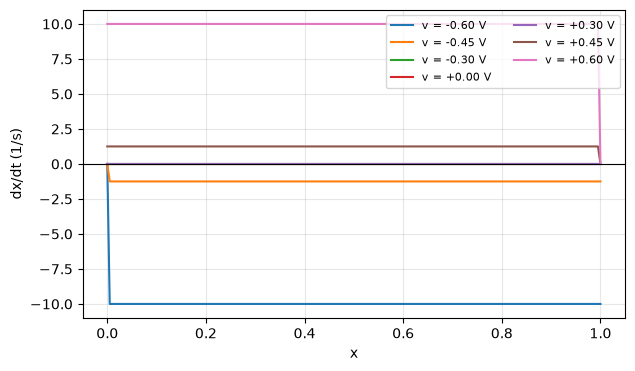

[PASS] no motion inside the dead band
[PASS] rate is independent of x inside (0, 1)
[PASS] rate at 0.6 V is 8 times the rate at 0.45 V (cubic law: (1)^3 vs (0.5)^3)


True

In [2]:
m = VTEAM2015()
print(m.params)
xs = np.linspace(0.0, 1.0, 201)
drm = dynamic_route_map(m, xs, [-0.6, -0.45, -0.3, 0.0, 0.3, 0.45, 0.6])
fig, ax = plt.subplots()
for v, rate in drm.items():
    ax.plot(xs, rate, label=f"v = {v:+.2f} V")
ax.axhline(0, color="k", lw=0.8); ax.set_xlabel("x"); ax.set_ylabel("dx/dt (1/s)"); ax.legend(ncol=2, fontsize=8)
show(fig)
caption("Dynamic route map of VTEAM: inside the dead band (|v| ≤ 0.3 V) the rate is zero for every "
        "state; outside it the rate is constant in x (rectangular window) and grows as a cube of the "
        "overdrive. Positive voltage moves x up (towards R_off).")
check("no motion inside the dead band", all(np.all(drm[v] == 0.0) for v in (-0.3, 0.0, 0.3)))
check("rate is independent of x inside (0, 1)", np.allclose(drm[0.6][1:-1], drm[0.6][100]))
check("rate at 0.6 V is 8 times the rate at 0.45 V (cubic law: (1)^3 vs (0.5)^3)", np.isclose(drm[0.6][100] / drm[0.45][100], 8.0))

<a id="sec-10"></a>

## 10. The switching loop

A sine that exceeds both thresholds switches the device fully in each half-cycle. The I-V loop
is no longer the smooth lens of chapter 1: the current follows the $R_{\rm on}$ line until
$v_{\rm off}$, then bends as $x$ runs to 1 (RESET), and follows the $R_{\rm off}$ line on the
way back until $v_{\rm on}$ SETs it again. Below the thresholds the loop is a straight line —
a read of ±0.2 V costs nothing.

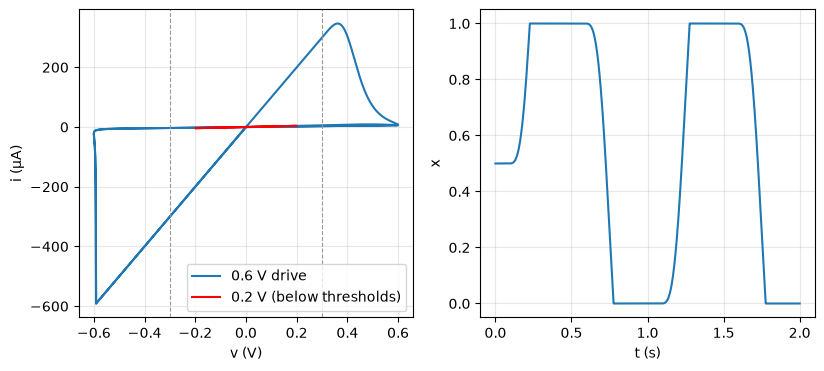

[PASS] the loop is pinched and spans R_on to R_off
[PASS] full switching in both directions
[PASS] a 0.2 V drive leaves the state untouched


True

In [3]:
res = iv_sweep(VTEAM2015(), 0.6, 1.0, cycles=2, n_per_cycle=2000)
met = loop_metrics(res)
small = iv_sweep(VTEAM2015(), 0.2, 1.0, cycles=1, n_per_cycle=1000)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.0))
ax1.plot(res.v, 1e6 * res.i, label="0.6 V drive"); ax1.plot(small.v, 1e6 * small.i, "r", label="0.2 V (below thresholds)")
ax1.axvline(0.3, color="0.6", ls="--", lw=0.8); ax1.axvline(-0.3, color="0.6", ls="--", lw=0.8)
ax1.set_xlabel("v (V)"); ax1.set_ylabel("i (µA)"); ax1.legend()
ax2.plot(res.t, res.x); ax2.set_xlabel("t (s)"); ax2.set_ylabel("x")
show(fig)
caption("Left: the VTEAM loop under a 0.6 V, 1 Hz sine (two periods) with the thresholds marked, "
        "and the straight line of a 0.2 V drive that never crosses them. Right: the state "
        "switching fully between 0 (R_on) and 1 (R_off) every half-period.")
check("the loop is pinched and spans R_on to R_off", met["pinched_at_origin"] and np.isclose(met["r_min"], 1e3) and np.isclose(met["r_max"], 1e5))
check("full switching in both directions", res.x.min() == 0.0 and res.x.max() == 1.0)
check("a 0.2 V drive leaves the state untouched", np.all(small.x == small.x[0]))

<a id="sec-11"></a>

## 11. Thresholds, exponents and asymmetry

The two thresholds and exponents are independent; real devices are usually **asymmetric**
(SET faster or at a lower voltage than RESET). The switching time from one end to the other
at a constant overdrive follows directly from the rate law: with the rectangular window,
$t_{\rm switch} = 1 / \big[k\,(v/v_{\rm th} - 1)^{\alpha}\big]$. Pulses of a given width
therefore switch the device only above a well-defined amplitude — the basis of programming
in chapter 5.

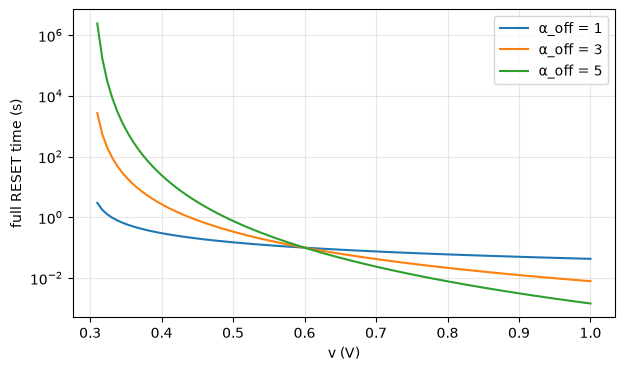

[PASS] t_switch = 1/(k (v/v_th - 1)^α) at 0.6 V is 0.1 s
[PASS] at 0.9 V it is 8 times shorter
[PASS] an asymmetric device SETs faster than it RESETs at ±0.6 V — 0.0025 s vs 0.100 s


True

In [4]:
def switch_time(model, v):
    rate = abs(model.state_derivative(0.5, v))
    return np.inf if rate == 0 else 1.0 / rate

vs = np.linspace(0.31, 1.0, 100)
fig, ax = plt.subplots()
for alpha in (1, 3, 5):
    m = VTEAM2015(alpha_off=alpha)
    ax.semilogy(vs, [switch_time(m, v) for v in vs], label=f"α_off = {alpha}")
ax.set_xlabel("v (V)"); ax.set_ylabel("full RESET time (s)"); ax.legend()
show(fig)
caption("Time for a full RESET (x: 0 → 1) at constant voltage for three exponents α_off "
        "(k_off = 10 s⁻¹, v_off = 0.3 V): a larger exponent makes the device both slower near "
        "threshold and faster far above it.")
m3 = VTEAM2015()
check("t_switch = 1/(k (v/v_th - 1)^α) at 0.6 V is 0.1 s", np.isclose(switch_time(m3, 0.6), 0.1))
check("at 0.9 V it is 8 times shorter", np.isclose(switch_time(m3, 0.9) * 8, 0.1))
asym = VTEAM2015(k_on=-50.0, v_on=-0.2)
check("an asymmetric device SETs faster than it RESETs at ±0.6 V", switch_time(asym, -0.6) < switch_time(asym, 0.6),
      f"{switch_time(asym, -0.6):.4f} s vs {switch_time(asym, 0.6):.3f} s")

<a id="sec-12"></a>

## 12. Reading without writing: the dead band as a memory guarantee

The dead band is what makes a memristor a *memory*: a read pulse inside $[v_{\rm on}, v_{\rm off}]$
leaves the state exactly where it was, however many times it is applied. Contrast the linear
ion drift model, where a thousand 0.1 V reads move the state measurably.

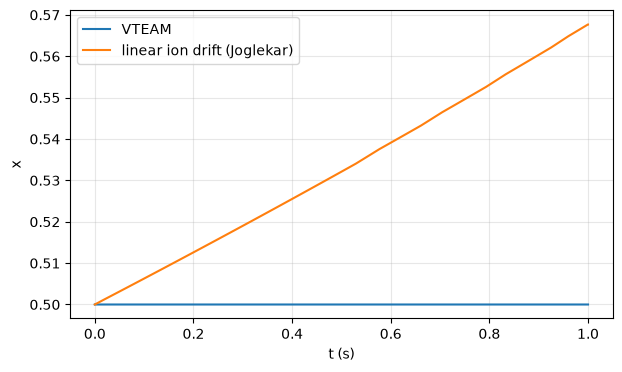

[PASS] VTEAM: 1000 reads change nothing
[PASS] linear ion drift: the reads move the state — Δx = +6.77e-02


True

In [5]:
n_reads = 1000
t = np.linspace(0.0, n_reads * 1e-3, n_reads * 20 + 1)
v = pulse_train(t, 0.1, width=0.5e-3, period=1e-3, n_pulses=n_reads)        # 1000 reads of 0.1 V, 0.5 ms
r_vteam = simulate(VTEAM2015(x0=0.5), t, v)
r_lid = simulate(LinearIonDrift(window="joglekar", x0=0.5), t, v)
fig, ax = plt.subplots()
ax.plot(r_vteam.t, r_vteam.x, label="VTEAM"); ax.plot(r_lid.t, r_lid.x, label="linear ion drift (Joglekar)")
ax.set_xlabel("t (s)"); ax.set_ylabel("x"); ax.legend()
show(fig)
caption("One thousand 0.1 V read pulses: the VTEAM state is untouched (dead band), the linear "
        "ion drift state drifts with every read.")
check("VTEAM: 1000 reads change nothing", np.all(r_vteam.x == 0.5))
check("linear ion drift: the reads move the state", abs(r_lid.x[-1] - 0.5) > 1e-4, f"Δx = {r_lid.x[-1] - 0.5:+.2e}")

### Exercises for chapter 3

**3.1** Find, by bisection on the amplitude, the smallest sine amplitude (1 Hz) for which the
default VTEAM device reaches $x = 1$ within the first half-period.

**3.2** Turn the window off (`window=0`) and repeat §10. What changes, and what does the
driver do at the boundaries?

In [6]:
# 3.1 — bisection on the amplitude. The answer is NOT "just above v_off": with a cubic rate law
#       the sine spends most of the half-period barely above threshold, so the state gain
#       ∫ k_off (A sin(2πt)/v_off − 1)^3 dt over the half-period reaches 1 only near A ≈ 0.57 V.
lo, hi = 0.30, 0.60
for _ in range(20):
    mid = 0.5 * (lo + hi)
    r = iv_sweep(VTEAM2015(x0=0.0), mid, 1.0, cycles=0.5, n_per_cycle=4000)
    if r.x.max() >= 1.0:
        hi = mid
    else:
        lo = mid
from scipy.integrate import quad
from scipy.optimize import brentq
gain = lambda A: quad(lambda t: 10.0 * max(0.0, A * np.sin(2 * np.pi * t) / 0.3 - 1.0) ** 3, 0.0, 0.5, limit=200)[0]
A_analytic = brentq(lambda A: gain(A) - 1.0, 0.31, 0.6)
check("3.1 the smallest switching amplitude matches the analytic half-period gain (≈ 0.566 V)",
      np.isclose(hi, A_analytic, atol=2e-3), f"bisection {hi:.4f} V, analytic {A_analytic:.4f} V")

# 3.2 — without the window the rate law is the same and the driver's clip bounds the state. The two
#       trajectories differ only at the grid points where the state hits a boundary: with the window
#       the RK4 stages evaluated *at* the clipped boundary return 0, so the windowed run arrives one
#       step later (pitfall 4 of references/pitfalls.md). Measured: 3 of 4001 points, |Δx| ≤ 1.7e-4.
r_free = iv_sweep(VTEAM2015(window=0), 0.6, 1.0, cycles=2, n_per_cycle=2000)
r_win = iv_sweep(VTEAM2015(window=1), 0.6, 1.0, cycles=2, n_per_cycle=2000)
dx = np.abs(r_free.x - r_win.x)
check("3.2 with or without the window the trajectories coincide except for one grid step at each boundary hit",
      dx.max() < 1e-3 and np.sum(dx > 1e-8) <= 4, f"max |Δx| = {dx.max():.1e} at {int(np.sum(dx > 1e-8))} points")

[PASS] 3.1 the smallest switching amplitude matches the analytic half-period gain (≈ 0.566 V) — bisection 0.5663 V, analytic 0.5663 V
[PASS] 3.2 with or without the window the trajectories coincide except for one grid step at each boundary hit — max |Δx| = 1.6e-04 at 3 points


True

In [7]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 3 — checks passed : {_CHECKS['pass']}")
print(f"chapter 3 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 3 — checks passed : 13
chapter 3 — checks failed : 0
wall time                 : 4 s
Every quantitative claim in this notebook was verified in this run.
